<a href="https://colab.research.google.com/github/EnzoCaetano015/Fiap-JupyterNotebooks/blob/main/Da_Terra_ao_C%C3%B3digo_Automatizando_a_Classifica%C3%A7%C3%A3o_de_Gr%C3%A3os_com_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Grãos de Trigo com CRISP-DM

**Dataset:** Seeds Dataset — UCI Machine Learning Repository  
**Objetivo:** construir, comparar, otimizar e interpretar modelos de Machine Learning para classificar grãos de trigo nas variedades **Kama**, **Rosa** e **Canadian** com base em características físicas.

---

## Metodologia CRISP-DM usada neste notebook

1. **Entendimento do negócio:** compreender o problema de classificação manual de grãos em cooperativas agrícolas.
2. **Entendimento dos dados:** analisar estrutura, estatísticas, distribuições e relações entre atributos.
3. **Preparação dos dados:** tratar valores ausentes, separar variáveis independentes e alvo, dividir treino/teste e escalar atributos.
4. **Modelagem:** treinar diferentes algoritmos de classificação.
5. **Avaliação:** comparar acurácia, precisão, recall, F1-score e matrizes de confusão.
6. **Interpretação:** extrair insights sobre desempenho dos modelos e importância das características.

## 1. Entendimento do Negócio

Em cooperativas agrícolas de pequeno porte, a classificação dos grãos costuma depender de avaliação manual. Esse processo pode ser lento, caro e sujeito a inconsistências humanas.

Neste projeto, a proposta é automatizar a classificação usando aprendizado de máquina supervisionado. O modelo receberá medidas físicas do grão e retornará a variedade provável:

- **Kama**
- **Rosa**
- **Canadian**

Na prática, isso pode ajudar a cooperativa a:

- acelerar a triagem dos grãos;
- reduzir erros de classificação;
- padronizar decisões;
- apoiar controle de qualidade.

In [ ]:
# ============================================================
# 0. Bibliotecas
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Entendimento dos Dados

O Seeds Dataset contém medições geométricas de grãos de trigo. Cada linha representa uma amostra de grão e cada coluna representa uma característica física.

A variável alvo é a classe do trigo:

- `1`: Kama
- `2`: Rosa
- `3`: Canadian

In [ ]:
# ============================================================
# 1. Carregamento do dataset oficial da UCI
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

colunas = [
    "area",
    "perimetro",
    "compacidade",
    "comprimento_nucleo",
    "largura_nucleo",
    "coef_assimetria",
    "comprimento_sulco",
    "classe"
]

# O arquivo da UCI é separado por espaços/tabulações e não possui cabeçalho.
df = pd.read_csv(url, sep=r"\s+", header=None, names=colunas)

mapa_classes = {
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
}

df["variedade"] = df["classe"].map(mapa_classes)

df.head()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe,variedade
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [ ]:
# Estrutura geral do dataset
print("Dimensões do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nQuantidade por classe:")
print(df["variedade"].value_counts())

Dimensões do dataset: (210, 9)

Tipos de dados:
area                  float64
perimetro             float64
compacidade           float64
comprimento_nucleo    float64
largura_nucleo        float64
coef_assimetria       float64
comprimento_sulco     float64
classe                  int64
variedade              object
dtype: object

Quantidade por classe:
variedade
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


In [ ]:
# Primeiras e últimas linhas para inspecionar a estrutura
display(df.head())
display(df.tail())

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe,variedade
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe,variedade
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3,Canadian
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3,Canadian
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3,Canadian
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3,Canadian
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3,Canadian


## 2.1 Estatísticas Descritivas

Aqui calculamos:

- média;
- mediana;
- desvio padrão;
- mínimo;
- máximo;
- quartis.

Essas medidas ajudam a entender tendência central, dispersão e escala dos atributos.

In [ ]:
atributos = [
    "area",
    "perimetro",
    "compacidade",
    "comprimento_nucleo",
    "largura_nucleo",
    "coef_assimetria",
    "comprimento_sulco"
]

estatisticas = df[atributos].agg(["mean", "median", "std", "min", "max"]).T
estatisticas.columns = ["media", "mediana", "desvio_padrao", "minimo", "maximo"]
estatisticas

,media,mediana,desvio_padrao,minimo,maximo
area,14.847524,14.35500,2.909699,10.5900,21.1800
perimetro,14.559286,14.32000,1.305959,12.4100,17.2500
compacidade,0.870999,0.87345,0.023629,0.8081,0.9183
comprimento_nucleo,5.628533,5.52350,0.443063,4.8990,6.6750
largura_nucleo,3.258605,3.23700,0.377714,2.6300,4.0330
coef_assimetria,3.700201,3.59900,1.503557,0.7651,8.4560
comprimento_sulco,5.408071,5.22300,0.491480,4.5190,6.5500


In [ ]:
# Describe completo
df[atributos].describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimetro,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compacidade,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
comprimento_nucleo,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
largura_nucleo,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
coef_assimetria,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
comprimento_sulco,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500


## 2.2 Valores Ausentes

Antes de treinar modelos, precisamos verificar se existem dados faltantes. Se houvesse valores ausentes, poderíamos removê-los ou preenchê-los com média/mediana. Neste dataset, a expectativa é não encontrar ausentes.

In [ ]:
ausentes = df.isnull().sum()
ausentes

,0
area,0
perimetro,0
compacidade,0
comprimento_nucleo,0
largura_nucleo,0
coef_assimetria,0
comprimento_sulco,0
classe,0
variedade,0


In [ ]:
if ausentes.sum() == 0:
    print("Não há valores ausentes no dataset.")
else:
    print("Existem valores ausentes. Aplicando preenchimento pela mediana nos atributos numéricos.")
    df[atributos] = df[atributos].fillna(df[atributos].median())

Não há valores ausentes no dataset.


## 2.3 Distribuição das Características

Histogramas mostram como cada atributo se distribui. Boxplots ajudam a identificar dispersão e possíveis outliers.

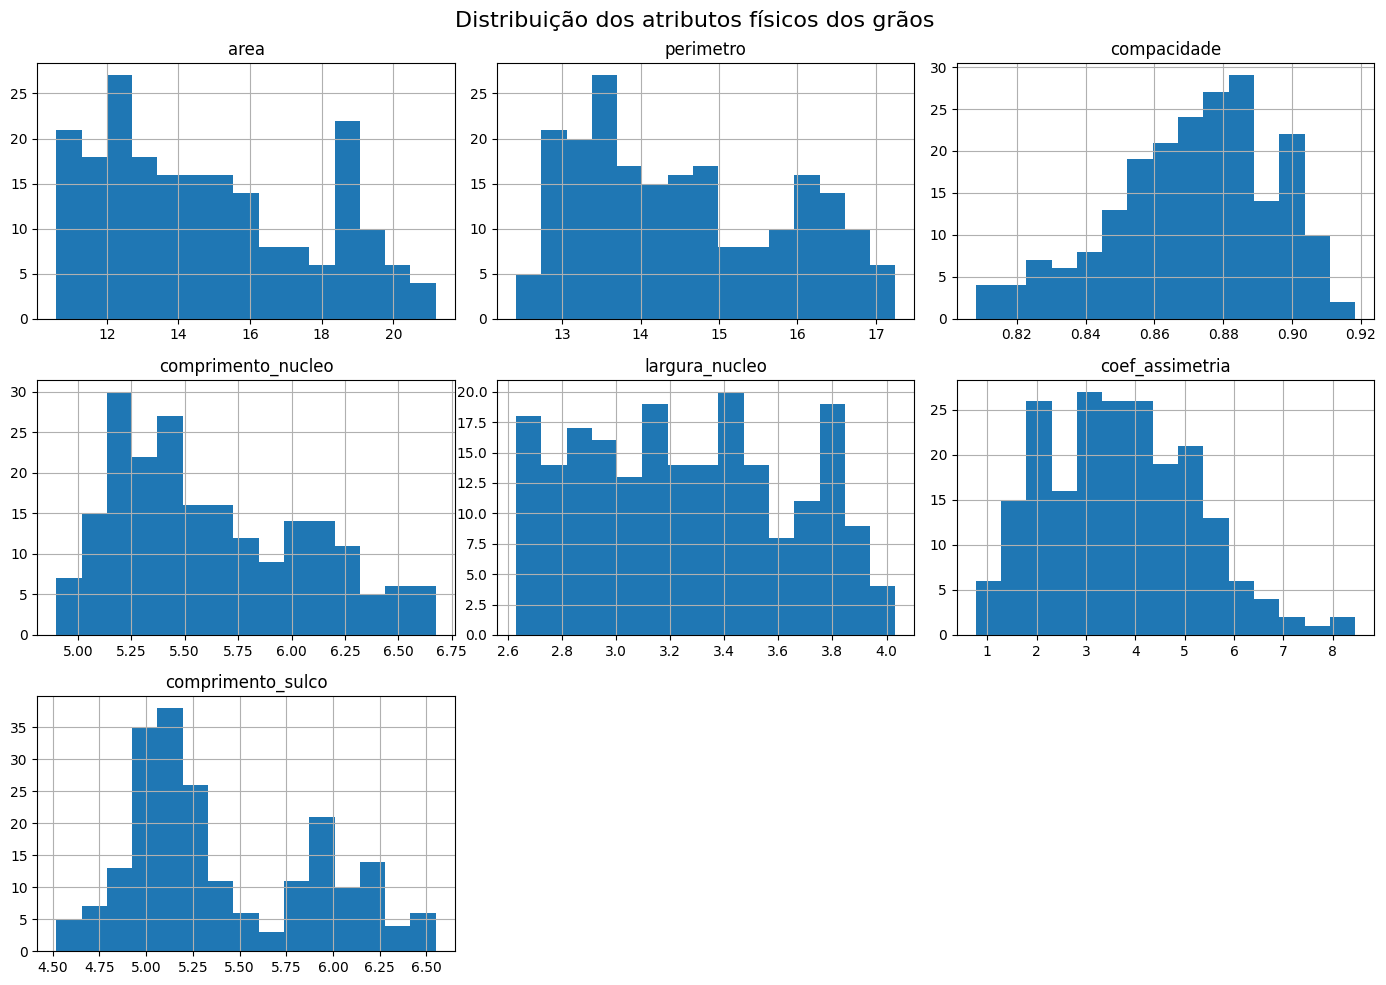

In [ ]:
# Histogramas
df[atributos].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distribuição dos atributos físicos dos grãos", fontsize=16)
plt.tight_layout()
plt.show()

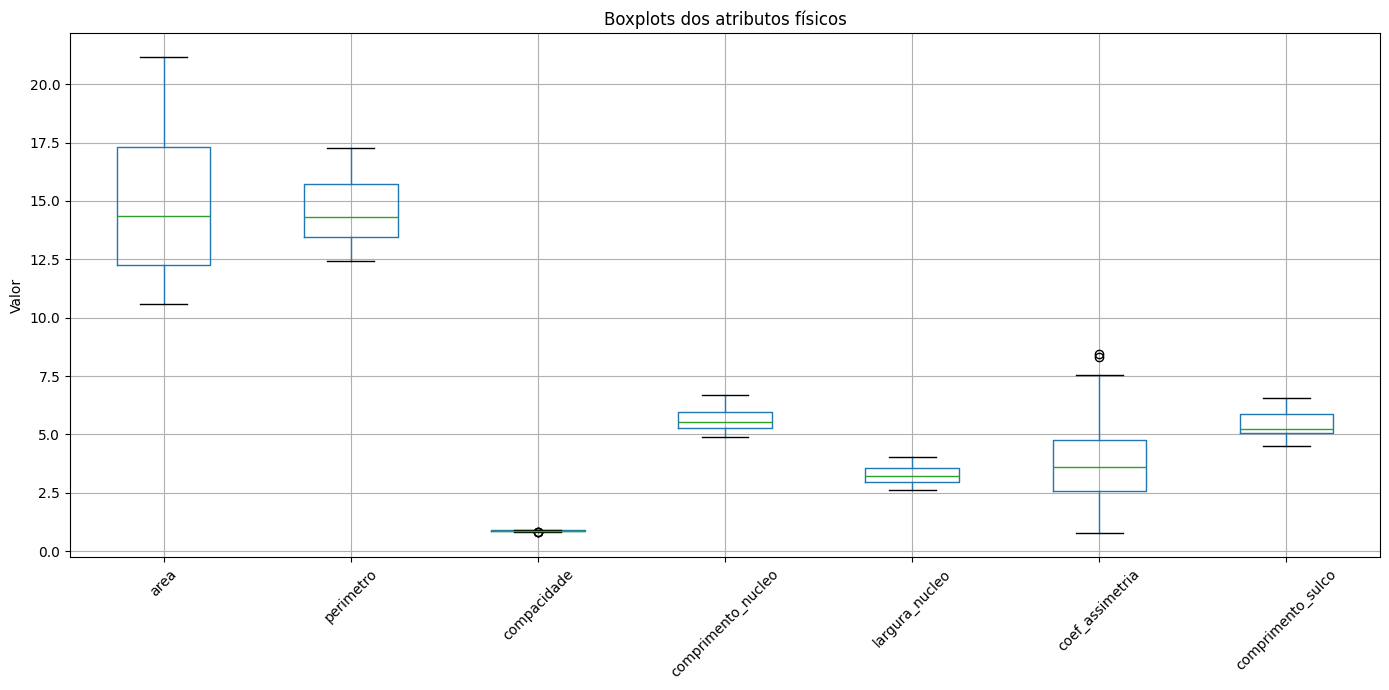

In [ ]:
# Boxplots gerais
plt.figure(figsize=(14, 7))
df[atributos].boxplot(rot=45)
plt.title("Boxplots dos atributos físicos")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

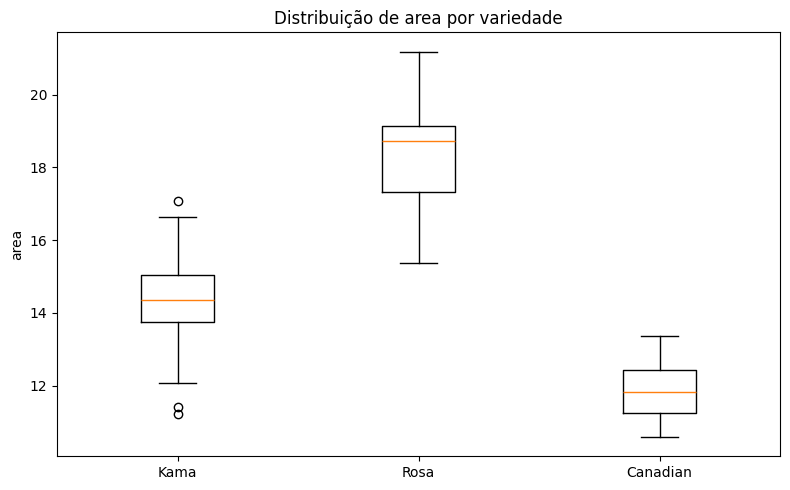

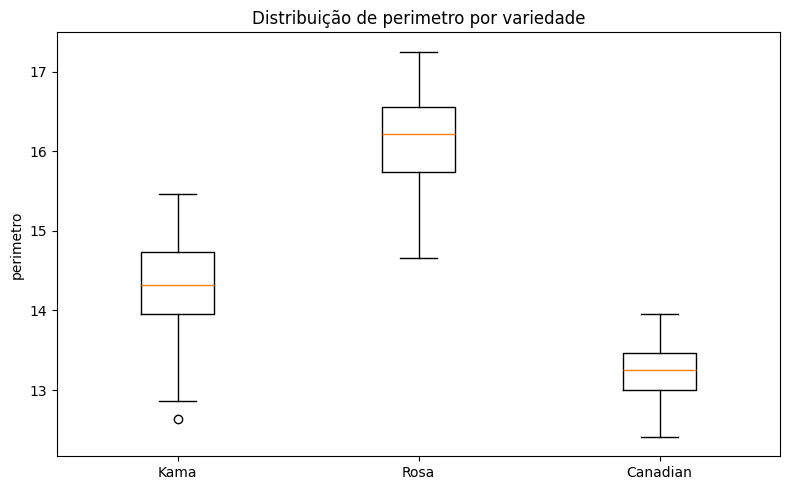

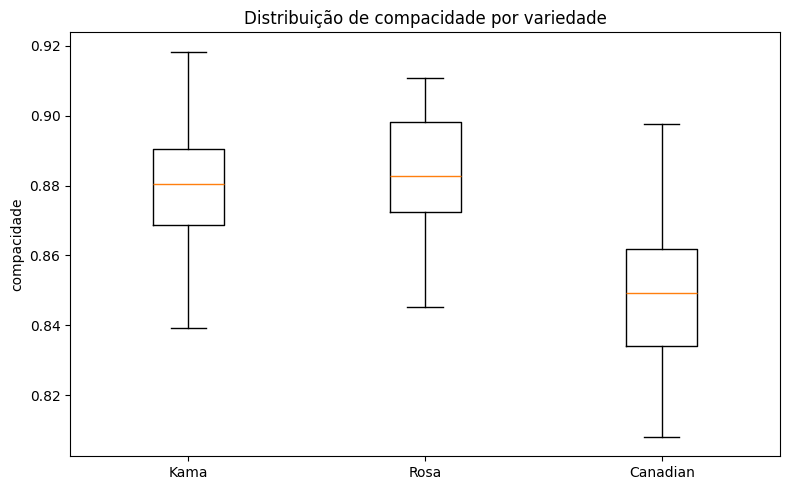

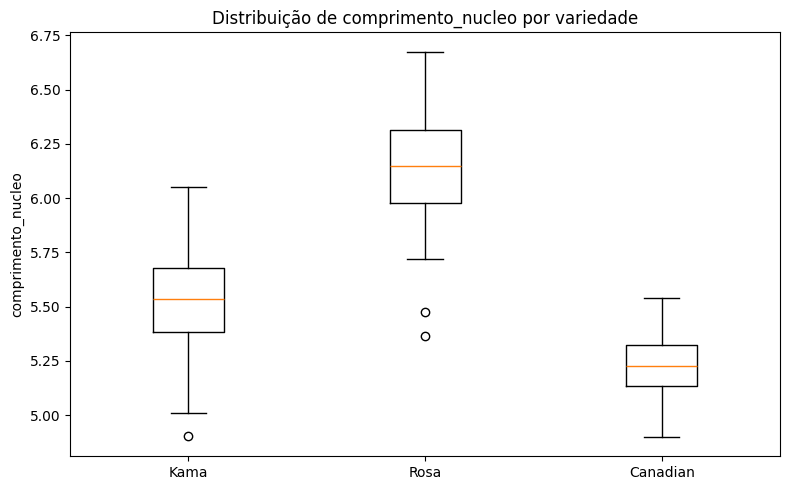

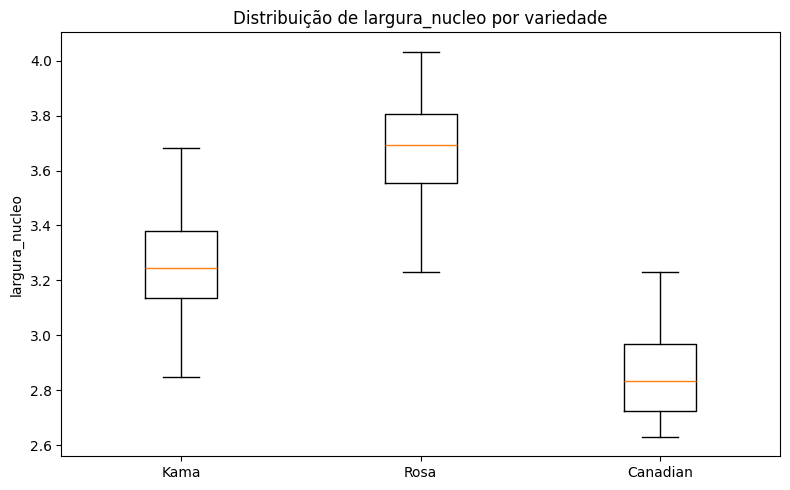

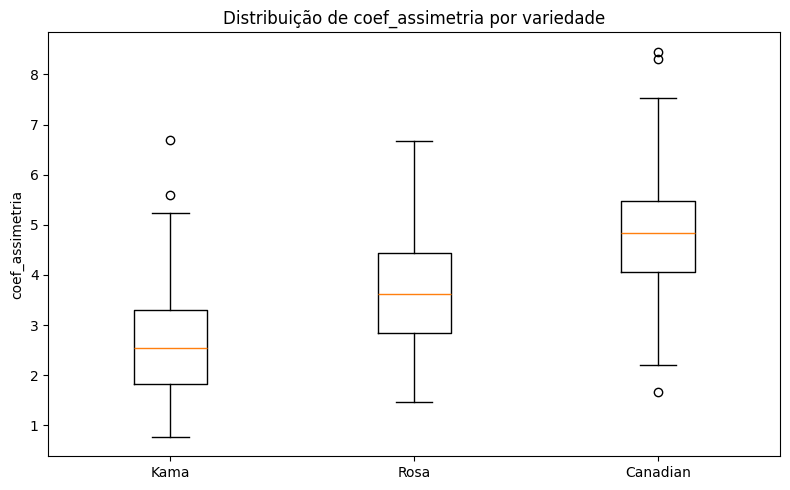

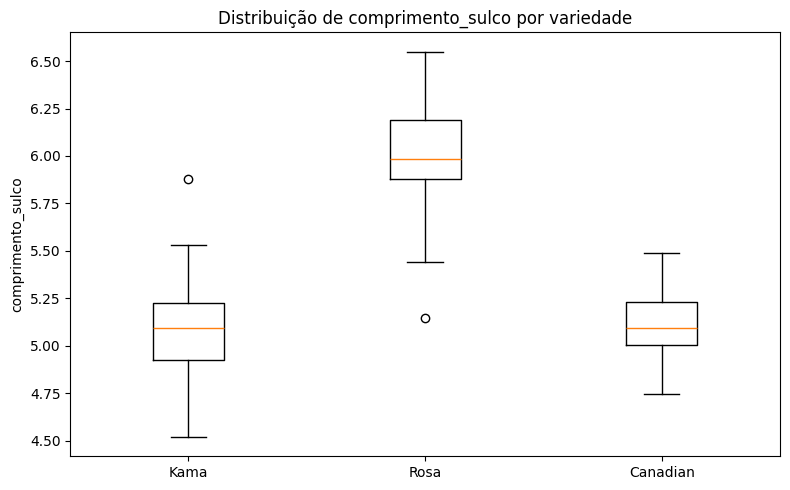

In [ ]:
# Boxplots por variedade
for atributo in atributos:
    plt.figure(figsize=(8, 5))
    dados_por_classe = [
        df[df["variedade"] == classe][atributo]
        for classe in ["Kama", "Rosa", "Canadian"]
    ]
    plt.boxplot(dados_por_classe, labels=["Kama", "Rosa", "Canadian"])
    plt.title(f"Distribuição de {atributo} por variedade")
    plt.ylabel(atributo)
    plt.tight_layout()
    plt.show()

## 2.4 Correlação entre Atributos

A matriz de correlação mostra quais atributos crescem ou diminuem juntos. Isso ajuda a identificar redundância entre variáveis e possíveis relações úteis para o modelo.

In [ ]:
correlacao = df[atributos].corr()
correlacao

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco
area,1.000000,0.994341,0.608288,0.949985,0.970771,-0.229572,0.863693
perimetro,0.994341,1.000000,0.529244,0.972422,0.944829,-0.217340,0.890784
compacidade,0.608288,0.529244,1.000000,0.367915,0.761635,-0.331471,0.226825
comprimento_nucleo,0.949985,0.972422,0.367915,1.000000,0.860415,-0.171562,0.932806
largura_nucleo,0.970771,0.944829,0.761635,0.860415,1.000000,-0.258037,0.749131
coef_assimetria,-0.229572,-0.217340,-0.331471,-0.171562,-0.258037,1.000000,-0.011079
comprimento_sulco,0.863693,0.890784,0.226825,0.932806,0.749131,-0.011079,1.000000


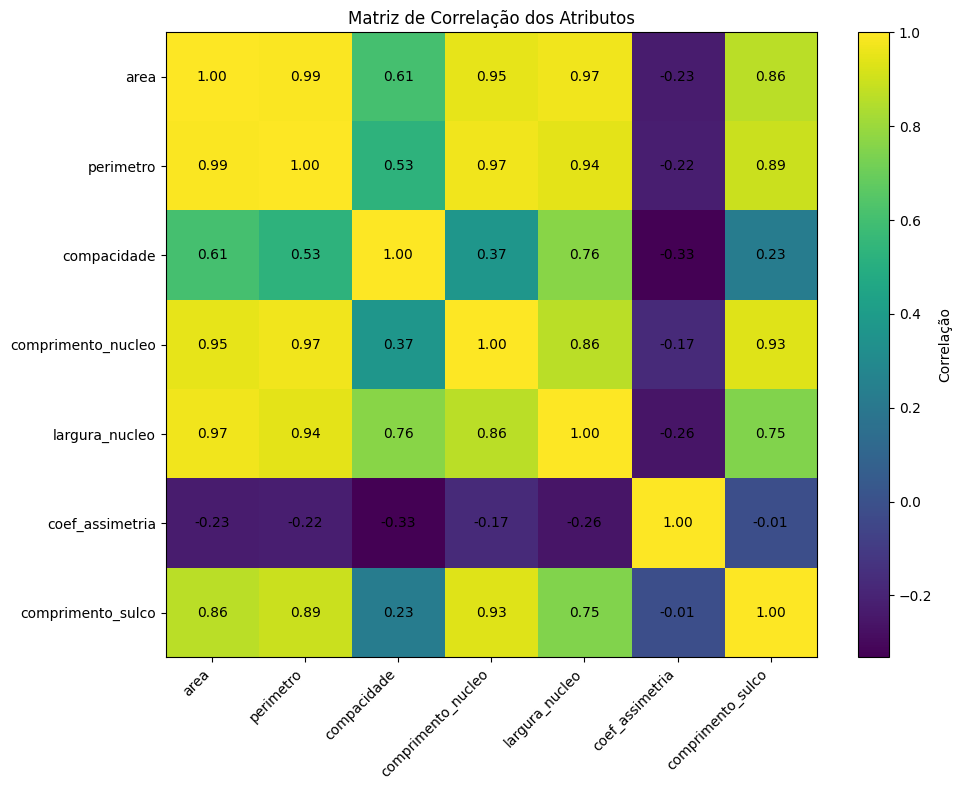

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(correlacao, cmap="viridis", aspect="auto")
plt.colorbar(label="Correlação")
plt.xticks(range(len(atributos)), atributos, rotation=45, ha="right")
plt.yticks(range(len(atributos)), atributos)
plt.title("Matriz de Correlação dos Atributos")

for i in range(len(atributos)):
    for j in range(len(atributos)):
        plt.text(j, i, f"{correlacao.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 2.5 Gráficos de Dispersão

Os gráficos de dispersão ajudam a verificar se as variedades formam grupos visualmente separáveis. Isso é importante porque modelos de classificação funcionam melhor quando existem padrões distinguíveis entre as classes.

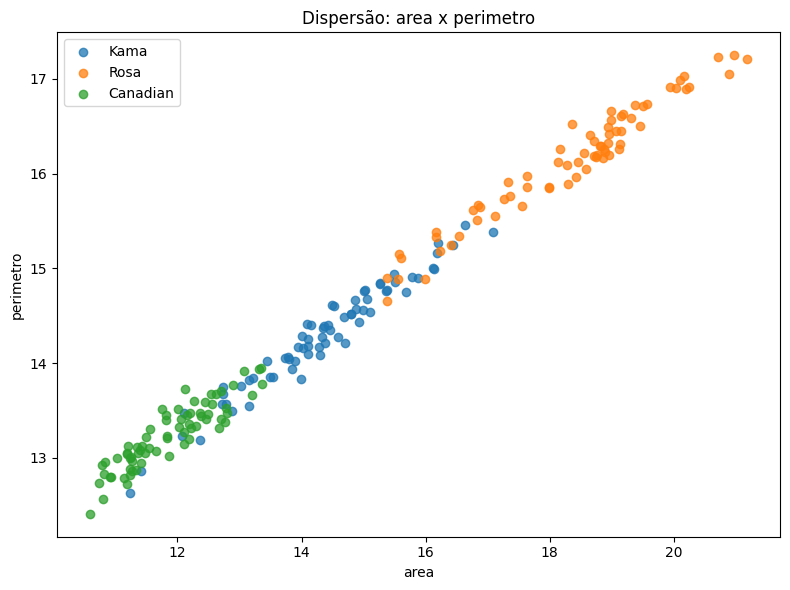

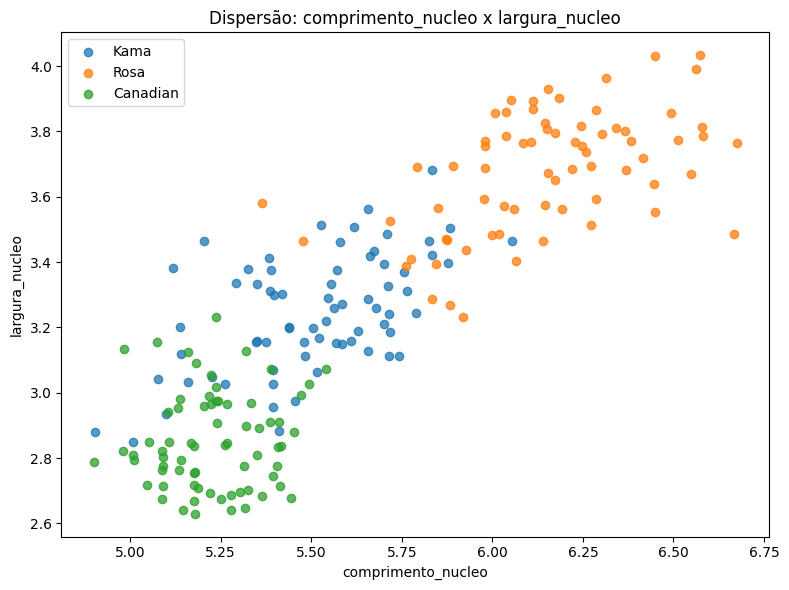

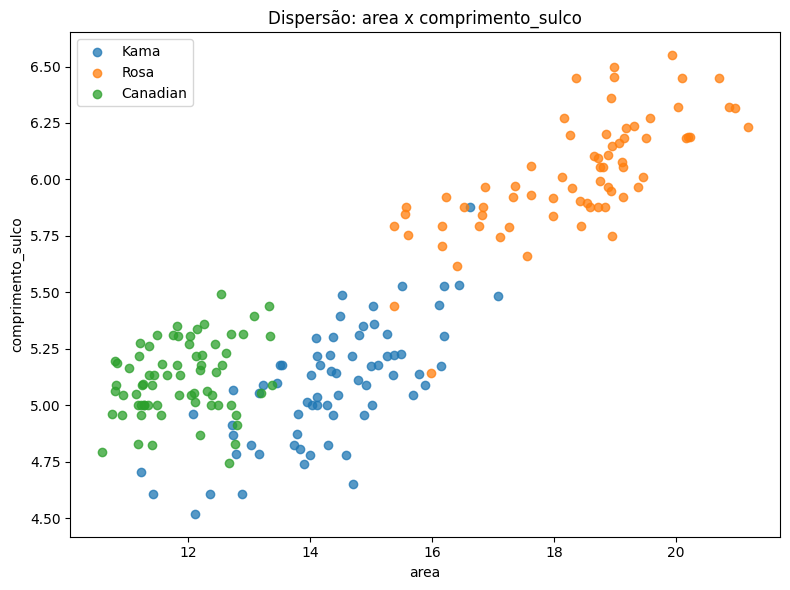

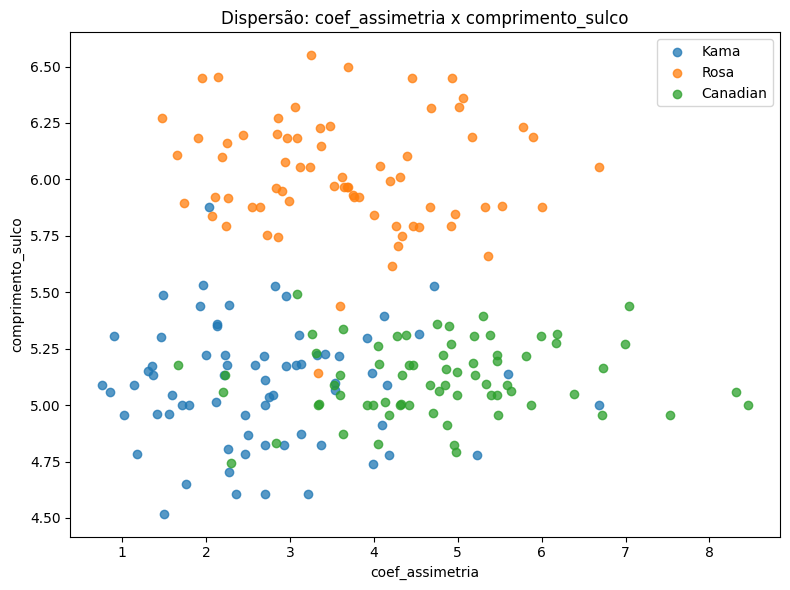

In [ ]:
cores = {
    "Kama": "tab:blue",
    "Rosa": "tab:orange",
    "Canadian": "tab:green"
}

pares = [
    ("area", "perimetro"),
    ("comprimento_nucleo", "largura_nucleo"),
    ("area", "comprimento_sulco"),
    ("coef_assimetria", "comprimento_sulco")
]

for x_col, y_col in pares:
    plt.figure(figsize=(8, 6))
    for variedade, cor in cores.items():
        subset = df[df["variedade"] == variedade]
        plt.scatter(subset[x_col], subset[y_col], label=variedade, alpha=0.75)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Dispersão: {x_col} x {y_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

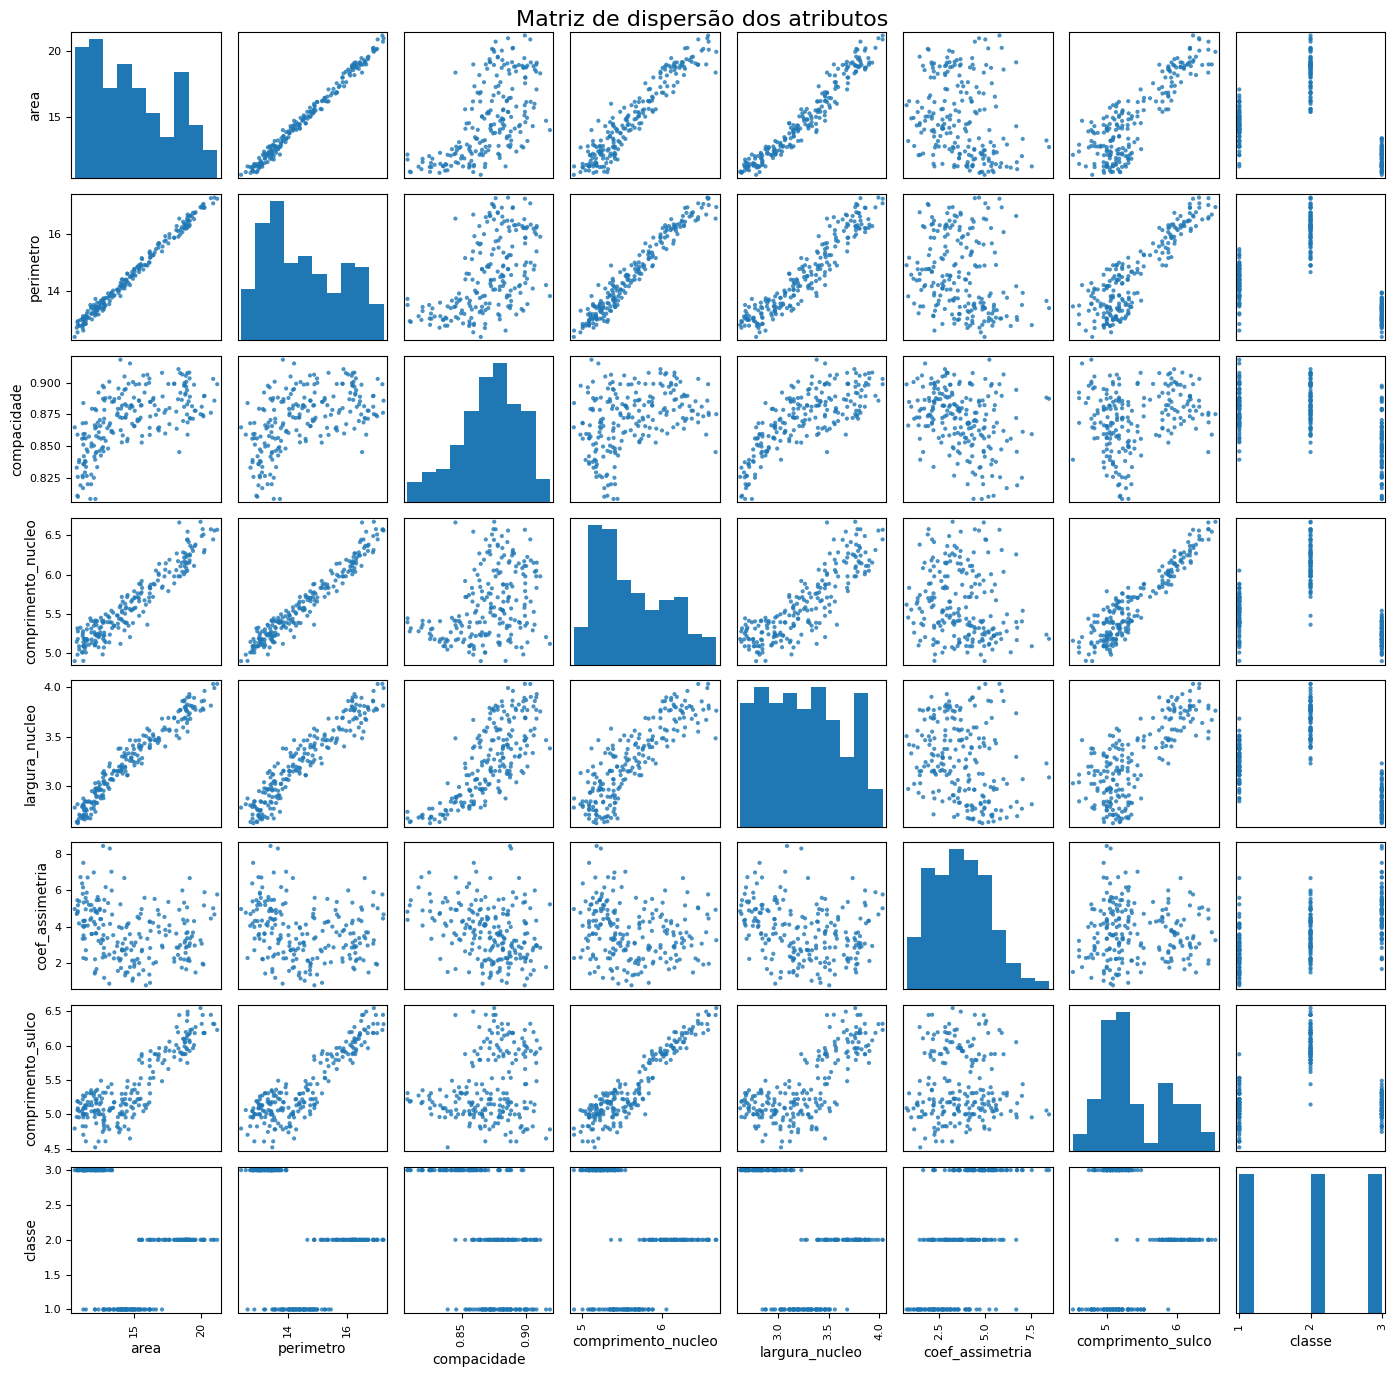

In [ ]:
# Matriz de dispersão completa
scatter_matrix(
    df[atributos + ["classe"]],
    figsize=(14, 14),
    diagonal="hist",
    alpha=0.8
)
plt.suptitle("Matriz de dispersão dos atributos", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Preparação dos Dados

Nesta etapa:

- separamos `X` com os atributos preditores;
- separamos `y` com a classe;
- dividimos os dados em treino e teste;
- aplicamos padronização quando necessário.

A padronização é importante para modelos sensíveis à escala, como **KNN**, **SVM** e **Regressão Logística**. Random Forest e Naive Bayes não dependem tanto da escala, mas vamos usar pipelines para manter o processo organizado.

In [ ]:
X = df[atributos]
y = df["classe"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).sort_index())

Treino: (147, 7)
Teste: (63, 7)

Distribuição no treino:
classe
1    0.333333
2    0.333333
3    0.333333
Name: proportion, dtype: float64

Distribuição no teste:
classe
1    0.333333
2    0.333333
3    0.333333
Name: proportion, dtype: float64


## 4. Modelagem Inicial

Vamos comparar pelo menos três algoritmos. Aqui usaremos cinco para deixar a análise mais forte:

- K-Nearest Neighbors;
- Support Vector Machine;
- Random Forest;
- Naive Bayes;
- Logistic Regression.

In [ ]:
modelos = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": Pipeline([
        ("model", GaussianNB())
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
}

In [ ]:
def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_test, y_pred),
        "precisao_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    }

resultados_iniciais = []

for nome, modelo in modelos.items():
    resultados_iniciais.append(
        avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test)
    )

resultados_iniciais_df = pd.DataFrame(resultados_iniciais).sort_values(
    by="f1_macro",
    ascending=False
)

resultados_iniciais_df

,modelo,acuracia,precisao_macro,recall_macro,f1_macro
2,Random Forest,0.920635,0.923942,0.920635,0.919170
0,KNN,0.873016,0.872144,0.873016,0.871284
1,SVM,0.873016,0.872144,0.873016,0.871284
4,Logistic Regression,0.857143,0.857143,0.857143,0.854294
3,Naive Bayes,0.825397,0.833928,0.825397,0.825060


KNN
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



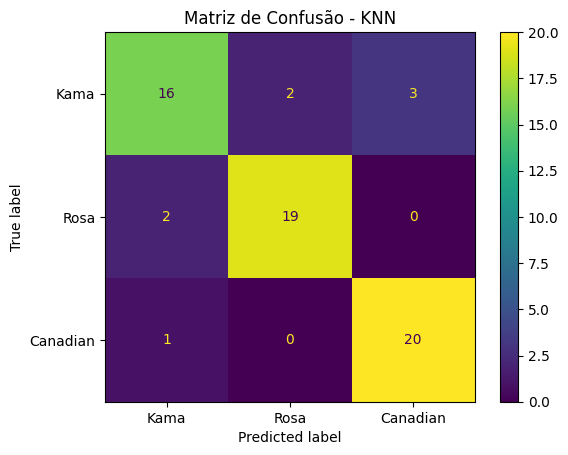

SVM
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



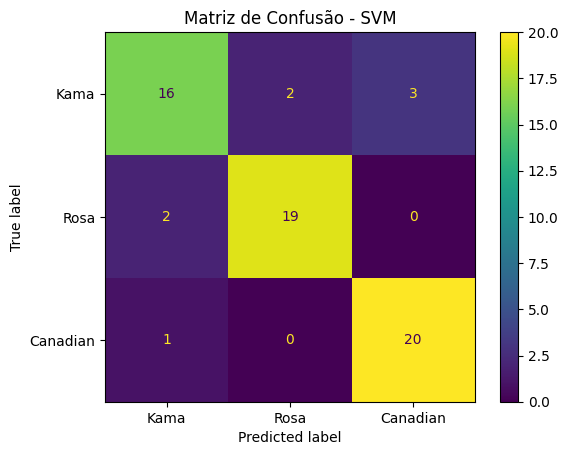

Random Forest
              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



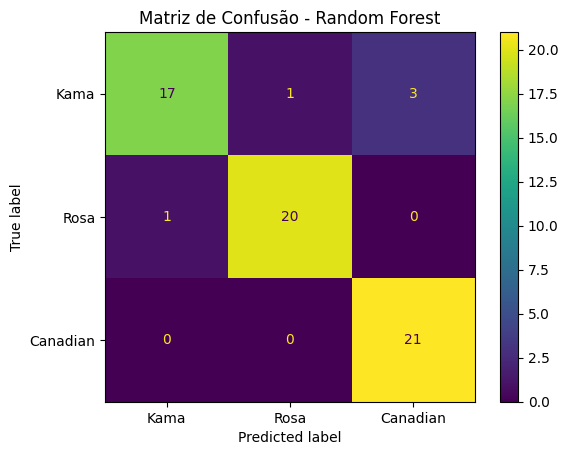

Naive Bayes
              precision    recall  f1-score   support

        Kama       0.73      0.76      0.74        21
        Rosa       0.94      0.76      0.84        21
    Canadian       0.83      0.95      0.89        21

    accuracy                           0.83        63
   macro avg       0.83      0.83      0.83        63
weighted avg       0.83      0.83      0.83        63



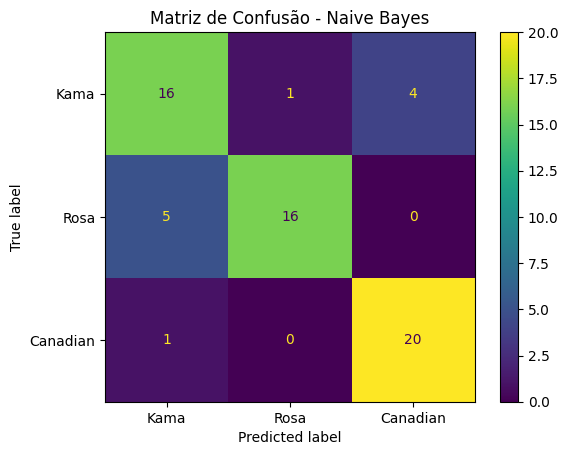

Logistic Regression
              precision    recall  f1-score   support

        Kama       0.83      0.71      0.77        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.83      0.95      0.89        21

    accuracy                           0.86        63
   macro avg       0.86      0.86      0.85        63
weighted avg       0.86      0.86      0.85        63



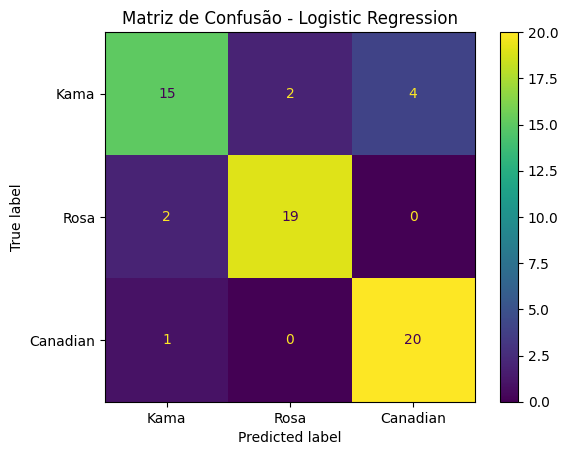

In [ ]:
# Relatório detalhado e matriz de confusão de cada modelo inicial
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print("=" * 80)
    print(nome)
    print("=" * 80)
    print(classification_report(y_test, y_pred, target_names=["Kama", "Rosa", "Canadian"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Kama", "Rosa", "Canadian"])
    disp.plot()
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

## 5. Otimização dos Modelos

Agora aplicamos **Grid Search** com validação cruzada estratificada. A ideia é testar combinações de hiperparâmetros e encontrar a configuração mais eficiente para cada modelo.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grades = {
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },
    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 4, 6],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Naive Bayes": {
        "model__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs"],
        "model__multi_class": ["auto"]
    }
}

In [ ]:
modelos_otimizados = {}
resultados_otimizados = []

for nome, modelo in modelos.items():
    print(f"Otimizando: {nome}")

    busca = GridSearchCV(
        estimator=modelo,
        param_grid=grades[nome],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )

    busca.fit(X_train, y_train)
    melhor_modelo = busca.best_estimator_
    modelos_otimizados[nome] = melhor_modelo

    y_pred = melhor_modelo.predict(X_test)

    resultados_otimizados.append({
        "modelo": nome,
        "melhor_f1_cv": busca.best_score_,
        "acuracia_teste": accuracy_score(y_test, y_pred),
        "precisao_macro_teste": precision_score(y_test, y_pred, average="macro"),
        "recall_macro_teste": recall_score(y_test, y_pred, average="macro"),
        "f1_macro_teste": f1_score(y_test, y_pred, average="macro"),
        "melhores_parametros": busca.best_params_
    })

resultados_otimizados_df = pd.DataFrame(resultados_otimizados).sort_values(
    by="f1_macro_teste",
    ascending=False
)

resultados_otimizados_df

Otimizando: KNN
Otimizando: SVM
Otimizando: Random Forest
Otimizando: Naive Bayes
Otimizando: Logistic Regression


,modelo,melhor_f1_cv,acuracia_teste,precisao_macro_teste,recall_macro_teste,f1_macro_teste,melhores_parametros
2,Random Forest,0.909605,0.904762,0.911186,0.904762,0.902510,"{'model__max_depth': 5, 'model__min_samples_le..."
4,Logistic Regression,0.951360,0.888889,0.889855,0.888889,0.888396,"{'model__C': 10, 'model__multi_class': 'auto',..."
0,KNN,0.946098,0.888889,0.887951,0.888889,0.888088,"{'model__n_neighbors': 3, 'model__p': 1, 'mode..."
1,SVM,0.959284,0.857143,0.855512,0.857143,0.854014,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
3,Naive Bayes,0.923387,0.825397,0.833928,0.825397,0.825060,{'model__var_smoothing': 1e-12}


In [ ]:
# Comparação entre modelos iniciais e otimizados
comparacao = resultados_iniciais_df.merge(
    resultados_otimizados_df,
    on="modelo",
    how="inner",
    suffixes=("_inicial", "_otimizado")
)

comparacao_resumida = comparacao[[
    "modelo",
    "acuracia",
    "f1_macro",
    "acuracia_teste",
    "f1_macro_teste"
]].rename(columns={
    "acuracia": "acuracia_inicial",
    "f1_macro": "f1_inicial",
    "acuracia_teste": "acuracia_otimizada",
    "f1_macro_teste": "f1_otimizado"
})

comparacao_resumida["ganho_f1"] = comparacao_resumida["f1_otimizado"] - comparacao_resumida["f1_inicial"]
comparacao_resumida.sort_values(by="f1_otimizado", ascending=False)

,modelo,acuracia_inicial,f1_inicial,acuracia_otimizada,f1_otimizado,ganho_f1
0,Random Forest,0.920635,0.919170,0.904762,0.902510,-0.016660
3,Logistic Regression,0.857143,0.854294,0.888889,0.888396,0.034102
1,KNN,0.873016,0.871284,0.888889,0.888088,0.016803
2,SVM,0.873016,0.871284,0.857143,0.854014,-0.017270
4,Naive Bayes,0.825397,0.825060,0.825397,0.825060,0.000000


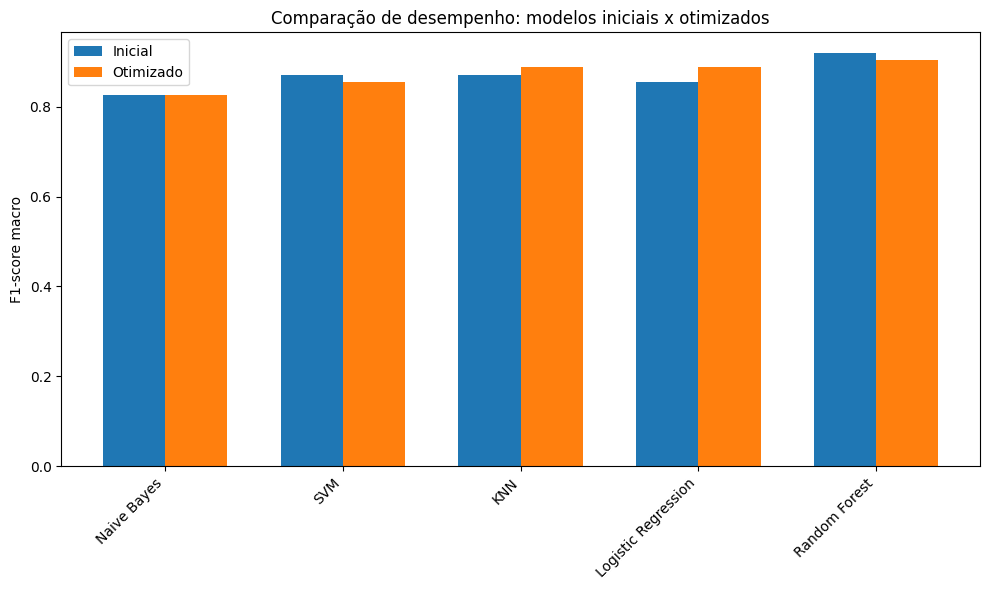

In [ ]:
# Visualização da comparação de F1-score
comparacao_plot = comparacao_resumida.sort_values(by="f1_otimizado", ascending=True)

x = np.arange(len(comparacao_plot))
largura = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - largura/2, comparacao_plot["f1_inicial"], largura, label="Inicial")
plt.bar(x + largura/2, comparacao_plot["f1_otimizado"], largura, label="Otimizado")
plt.xticks(x, comparacao_plot["modelo"], rotation=45, ha="right")
plt.ylabel("F1-score macro")
plt.title("Comparação de desempenho: modelos iniciais x otimizados")
plt.legend()
plt.tight_layout()
plt.show()

Melhor modelo: Random Forest
F1-score macro no teste: 0.9025098979332388
Melhores parâmetros:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 200}

Relatório detalhado do melhor modelo:
              precision    recall  f1-score   support

        Kama       0.94      0.76      0.84        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.84      1.00      0.91        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



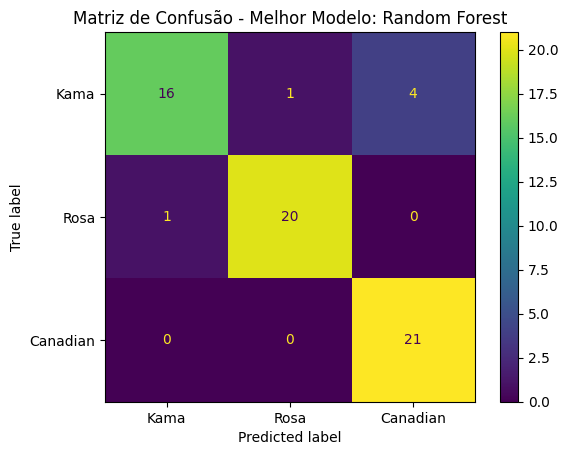

In [ ]:
# Melhor modelo final
melhor_linha = resultados_otimizados_df.iloc[0]
melhor_nome = melhor_linha["modelo"]
melhor_modelo = modelos_otimizados[melhor_nome]

print("Melhor modelo:", melhor_nome)
print("F1-score macro no teste:", melhor_linha["f1_macro_teste"])
print("Melhores parâmetros:")
print(melhor_linha["melhores_parametros"])

y_pred_melhor = melhor_modelo.predict(X_test)

print("\nRelatório detalhado do melhor modelo:")
print(classification_report(y_test, y_pred_melhor, target_names=["Kama", "Rosa", "Canadian"]))

cm = confusion_matrix(y_test, y_pred_melhor)
disp = ConfusionMatrixDisplay(cm, display_labels=["Kama", "Rosa", "Canadian"])
disp.plot()
plt.title(f"Matriz de Confusão - Melhor Modelo: {melhor_nome}")
plt.show()

## 6. Interpretação dos Resultados

Nesta etapa, analisamos:

- qual modelo teve melhor desempenho;
- se a otimização melhorou o resultado;
- quais classes foram mais confundidas;
- quais características parecem mais úteis para separar as variedades.

In [ ]:
# Importância das variáveis quando o melhor modelo for Random Forest.
# Se Random Forest não for o melhor, ainda treinamos uma Random Forest para interpretar importância.

rf_interpretavel = modelos_otimizados.get("Random Forest")
rf_interpretavel.fit(X_train, y_train)

rf_model = rf_interpretavel.named_steps["model"]

importancia = pd.DataFrame({
    "atributo": atributos,
    "importancia": rf_model.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancia

,atributo,importancia
0,area,0.233484
1,perimetro,0.216735
6,comprimento_sulco,0.172682
4,largura_nucleo,0.157812
3,comprimento_nucleo,0.113333
5,coef_assimetria,0.059828
2,compacidade,0.046125


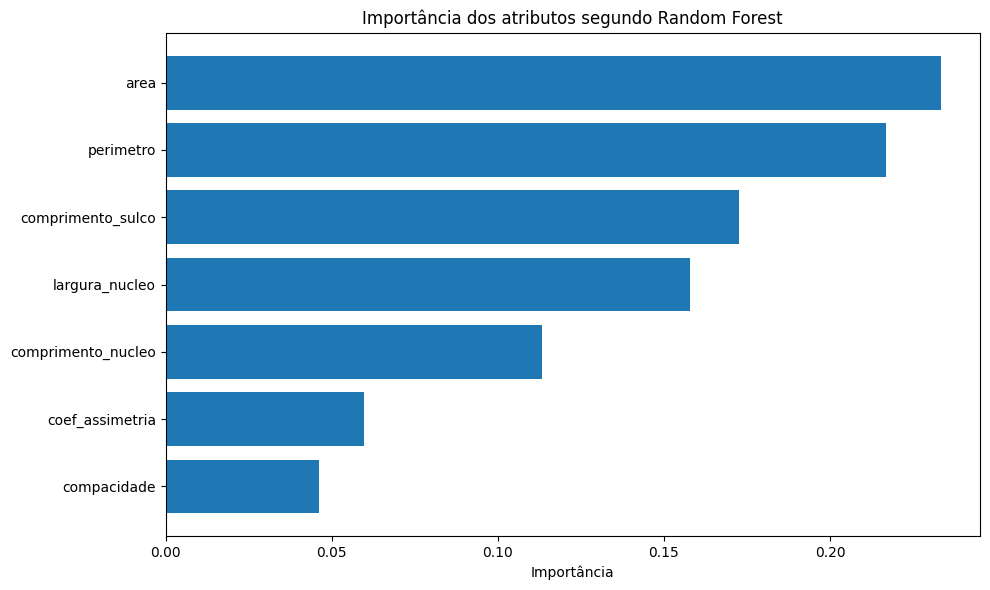

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importancia["atributo"], importancia["importancia"])
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.title("Importância dos atributos segundo Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Texto automático de conclusão com base nos resultados obtidos após executar o notebook

melhor = resultados_otimizados_df.iloc[0]
pior = resultados_otimizados_df.iloc[-1]
maior_importancia = importancia.iloc[0]

print("CONCLUSÃO AUTOMÁTICA")
print("-" * 80)
print(f"O melhor modelo foi {melhor['modelo']}, com F1-score macro de {melhor['f1_macro_teste']:.4f} no conjunto de teste.")
print(f"O modelo com menor desempenho após otimização foi {pior['modelo']}, com F1-score macro de {pior['f1_macro_teste']:.4f}.")
print(f"O atributo mais importante segundo Random Forest foi '{maior_importancia['atributo']}'.")
print("\nInterpretação:")
print("Como o dataset possui classes balanceadas, a acurácia é uma métrica útil, mas o F1-score macro é mais adequado para comparar o desempenho médio entre as três variedades.")
print("Modelos como SVM, KNN e Regressão Logística se beneficiam da padronização porque dependem de distância, margem ou coeficientes sensíveis à escala dos atributos.")
print("Na prática, o modelo pode apoiar cooperativas agrícolas ao reduzir dependência de inspeção manual e padronizar a classificação dos grãos.")

CONCLUSÃO AUTOMÁTICA
--------------------------------------------------------------------------------
O melhor modelo foi Random Forest, com F1-score macro de 0.9025 no conjunto de teste.
O modelo com menor desempenho após otimização foi Naive Bayes, com F1-score macro de 0.8251.
O atributo mais importante segundo Random Forest foi 'area'.

Interpretação:
Como o dataset possui classes balanceadas, a acurácia é uma métrica útil, mas o F1-score macro é mais adequado para comparar o desempenho médio entre as três variedades.
Modelos como SVM, KNN e Regressão Logística se beneficiam da padronização porque dependem de distância, margem ou coeficientes sensíveis à escala dos atributos.
Na prática, o modelo pode apoiar cooperativas agrícolas ao reduzir dependência de inspeção manual e padronizar a classificação dos grãos.


## 7. Conclusão Final

O projeto aplicou a metodologia CRISP-DM para resolver um problema realista de classificação agrícola.

**Principais conclusões esperadas após a execução:**

- O dataset é pequeno, limpo, balanceado e adequado para classificação supervisionada.
- As classes possuem 70 amostras cada, o que evita viés forte por desbalanceamento.
- A padronização é necessária para KNN, SVM e Regressão Logística.
- Modelos como SVM, KNN e Random Forest tendem a performar bem neste problema, pois os atributos físicos apresentam padrões separáveis.
- A matriz de confusão é essencial para enxergar quais variedades são confundidas.
- A classificação automatizada pode reduzir tempo, subjetividade e inconsistência na análise manual dos grãos.

**Decisão recomendada:** escolher o modelo com maior F1-score macro no teste, pois ele mede melhor o equilíbrio de desempenho entre as três variedades.

## 8. Referência do Dataset

Charytanowicz, M., Niewczas, J., Kulczycki, P., Kowalski, P., & Lukasik, S. (2010). **Seeds** [Dataset]. UCI Machine Learning Repository. DOI: 10.24432/C5H30K.